# 🧠 Fine-tuning de un modelo de análisis de sentimiento en español
### Reto Analítica Educativa · Samsung Innovation Campus · equipo Tech Tailors
**Ajuste fino (*fine-tuning*) de BETO sobre comentarios reales de estudiantes, usando RoBERTuito como modelo maestro (*weak supervision* / destilación de conocimiento).**

| | |
|---|---|
| Proyecto | Analítica Educativa — evaluaciones docentes |
| Notebook | 04 · Fine-tuning de sentimiento |
| Objetivo | Entrenar un clasificador propio de sentimiento y evaluar si mejora respecto al modelo base |
| Entradas | `data/raw/ReadyToTrain_comentarios_EN_ES_completo.xlsx` · `data/processed/benchmark_sentimiento.csv` |
| Salidas | `analisis_sentimientos/models/modelo_sentimiento_ft/` (pesos, excluidos de git) |
| Hardware | Apple Silicon (GPU vía MPS) — reproducible en CUDA o CPU |
| Equipo | Tech Tailors |

---

### Contenido

| § | Sección |
|---|---|
| 0 | [Marco teórico: transfer learning y fine-tuning](#0) |
| 1 | [Configuración del entorno](#1) |
| 2 | [Corpus de comentarios reales](#2) |
| 3 | [Generación de etiquetas (weak supervision)](#3) |
| 4 | [Balanceo de clases y particiones](#4) |
| 5 | [Hiperparámetros: qué significa cada uno](#5) |
| 6 | [Entrenamiento y curvas de aprendizaje](#6) |
| 7 | [Evaluación en el conjunto de prueba](#7) |
| 8 | [¿Mejoró? Comparación contra el modelo base y el maestro](#8) |
| 9 | [Persistencia del modelo](#9) |
| 10 | [Conclusiones, limitaciones y glosario](#10) |


<a id="0"></a>
## 0 · Marco teórico: transfer learning y fine-tuning

### 0.1 Las dos fases de un modelo de lenguaje

Un modelo de lenguaje moderno (tipo BERT) se construye en dos etapas claramente separadas:

| Fase | Qué aprende | Cómo | Quién lo hace | Analogía |
|---|---|---|---|---|
| **1. Preentrenamiento** | El **idioma**: gramática, semántica, contexto | Auto-supervisado: predecir palabras ocultas en millones de textos (*Masked Language Modeling*) | Universidades/empresas (costo alto en cómputo) | Una persona que **ya sabe español** |
| **2. Fine-tuning** | La **tarea**: clasificar sentimiento en 3 clases | Supervisado: ejemplos etiquetados (`texto → POS/NEU/NEG`) | Nosotros, en este notebook | Un **curso corto** de "clasificar opiniones" |

El mecanismo que conecta ambas fases se denomina **transfer learning** (aprendizaje por
transferencia): se *transfiere* el conocimiento lingüístico ya adquirido y solo se enseña la
tarea nueva. Esta es la razón por la que el fine-tuning requiere órdenes de magnitud menos datos
que entrenar una red desde cero.

Formalmente, durante el fine-tuning se añade al modelo preentrenado una **capa de clasificación**
(*classification head*) de $K$ salidas —aquí $K=3$— y se optimizan los parámetros $\theta$
minimizando la entropía cruzada:

$$\mathcal{L}(\theta) = -\frac{1}{N}\sum_{i=1}^{N}\sum_{k=1}^{K} y_{ik}\,\log \hat{p}_{ik}(\theta)$$

donde $y_{ik}$ es la etiqueta real (codificación *one-hot*) y $\hat{p}_{ik}$ la probabilidad
predicha para la clase $k$ en el ejemplo $i$.

### 0.2 Distinción importante: *usar* un modelo ≠ *ajustarlo*

En los notebooks anteriores (01–03) **usamos** modelos ya ajustados por sus autores, en modo
**inferencia** (solo predicción). Eso es aprovechar transfer learning hecho por terceros, pero
**no es fine-tuning**. En este notebook, por primera vez, **modificamos los pesos** de un modelo:
ese es el fine-tuning propiamente dicho.

### 0.3 El problema de este proyecto: no hay etiquetas humanas

El fine-tuning es **supervisado**: exige pares `(texto, etiqueta)`. El corpus de comentarios
reales disponible (100.000 registros, 29.243 textos únicos) contiene el texto en inglés y su
traducción al español, pero **ninguna columna de sentimiento**. Ante esta restricción existen
tres estrategias reconocidas en la literatura:

| Estrategia | Descripción | Viabilidad aquí |
|---|---|---|
| **Anotación manual** | Personas etiquetan miles de ejemplos | Ideal, pero costosa en tiempo |
| **Weak supervision / destilación** | Un modelo maestro genera *pseudo-etiquetas* con las que se entrena un modelo alumno | ✅ **La que aplicamos** |
| Aprendizaje no supervisado | Agrupamiento sin etiquetas | No produce las clases POS/NEU/NEG deseadas |

### 0.4 Destilación de conocimiento: alcance y límite teórico

Aplicamos **destilación** (*knowledge distillation*, Hinton et al., 2015): **RoBERTuito** —el
modelo con mejor desempeño según el benchmark del notebook 03— actúa como **maestro** y etiqueta
el corpus; **BETO** actúa como **alumno** y se entrena con esas pseudo-etiquetas.

> ⚠️ **Límite teórico que debe declararse.** El alumno aprende la *función* del maestro, de modo
> que hereda tanto sus aciertos como sus errores. Su techo de calidad es, por construcción, el
> desempeño del maestro: **una destilación no puede superar sistemáticamente a su maestro**. Es
> una hipótesis falsable, y en la §8 la contrastamos empíricamente.

### 0.5 Objetivos de aprendizaje de este notebook

1. Ejecutar un ciclo completo de fine-tuning: datos → particiones → tokenización → entrenamiento
   → evaluación → persistencia.
2. Comprender y justificar cada hiperparámetro (§5).
3. Diagnosticar **sobreajuste** mediante curvas de aprendizaje (§6).
4. Evaluar con rigor: distinguir entre *fidelidad al maestro* (§7) y *calidad real* frente a
   etiquetas humanas (§8).
5. Determinar empíricamente si el ajuste **mejora** el modelo base y qué límites tiene el método.


<a id="1"></a>
## 1 · Configuración del entorno

Fijamos la **semilla aleatoria** en todas las librerías para garantizar reproducibilidad, y
seleccionamos el dispositivo de cómputo. En Apple Silicon se utiliza **MPS** (*Metal Performance
Shaders*), el backend de GPU de PyTorch para chips M; `PYTORCH_ENABLE_MPS_FALLBACK=1` permite que
las operaciones aún no implementadas en MPS se ejecuten en CPU sin interrumpir el proceso.

In [1]:
%matplotlib inline
import os
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"   # operaciones no soportadas en MPS -> CPU
os.environ["TOKENIZERS_PARALLELISM"] = "false"    # evita advertencias de paralelismo
os.environ["TRANSFORMERS_VERBOSITY"] = "error"    # silencia logs informativos
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"

import sys, pathlib
RAIZ = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents] if (p/'src').is_dir())
if str(RAIZ) not in sys.path: sys.path.insert(0, str(RAIZ))

import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, accuracy_score, classification_report, confusion_matrix
from src import rutas

SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)

DEVICE = "mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu")
LABEL2ID = {"NEG": 0, "NEU": 1, "POS": 2}
ID2LABEL = {v: k for k, v in LABEL2ID.items()}
ORDEN = ["NEG", "NEU", "POS"]

INK, INK2, MUTED = "#0b0b0b", "#52514e", "#898781"
plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","axes.grid":True,
                     "grid.color":"#e1e0d9","axes.axisbelow":True,"axes.spines.top":False,
                     "axes.spines.right":False,"axes.titleweight":"bold","legend.frameon":False})

print(f"Dispositivo de cómputo : {DEVICE}")
print(f"Semilla aleatoria      : {SEED}")
print(f"PyTorch                : {torch.__version__}")

Dispositivo de cómputo : mps
Semilla aleatoria      : 42
PyTorch                : 2.13.0


<a id="2"></a>
## 2 · Corpus de comentarios reales

El corpus contiene comentarios auténticos de estudiantes sobre docentes (columna original en
inglés y su traducción al español). Trabajamos con la versión en español.

**Decisión metodológica: deduplicación.** Nos quedamos con los **textos únicos**. Entrenar con
duplicados no aporta información nueva —el modelo vería el mismo par (texto, etiqueta) muchas
veces— e introduce dos riesgos: (i) sobrerrepresentar frases frecuentes como *"Buen profesor"*,
sesgando el modelo; (ii) **fuga de información** entre particiones, ya que un texto idéntico
podría aparecer simultáneamente en entrenamiento y prueba, inflando artificialmente las métricas.

In [2]:
df_raw = pd.read_excel(rutas.datos_raw("ReadyToTrain_comentarios_EN_ES_completo.xlsx"))
print(f"Registros del archivo            : {len(df_raw):,}")

com = df_raw["Comentarios_ES"].dropna().astype(str).str.strip()
com = com[com.str.len() > 0]
print(f"Comentarios no vacíos            : {len(com):,}")

com = com.drop_duplicates().reset_index(drop=True)
print(f"Comentarios ÚNICOS (deduplicados): {len(com):,}")
print(f"Reducción por deduplicación      : {1 - len(com)/len(df_raw):.1%}")
print(f"Longitud media (palabras)        : {com.str.split().str.len().mean():.1f}")
com.head(8).to_frame("comentario")

Registros del archivo            : 100,000
Comentarios no vacíos            : 99,992
Comentarios ÚNICOS (deduplicados): 29,243
Reducción por deduplicación      : 70.8%
Longitud media (palabras)        : 13.9


,comentario
0,Bueno.
1,Profesor.
2,"Maestro amigable, pero sin suficiente capacida..."
3,Es un buen profesor.
4,es un buen profesor
5,"por encima de todo, nuestro profesor es un mod..."
6,Profesor excelente. Gran profesor.
7,Tiene una actitud excelente y un metodo de ens...


<a id="3"></a>
## 3 · Generación de etiquetas mediante *weak supervision*

Aplicamos **RoBERTuito** (maestro) sobre los comentarios únicos para producir las
**pseudo-etiquetas** que definirán la tarea de aprendizaje del alumno.

**Normalización de etiquetas.** Cada modelo del ecosistema utiliza nomenclaturas distintas
(`POS`/`POSITIVE`/`P`). Las unificamos al esquema `POS`/`NEU`/`NEG` para que las comparaciones
entre modelos sean válidas.

**Advertencia interpretativa.** Estas etiquetas **no constituyen verdad de terreno** (*ground
truth*). Son la salida de un modelo y, por tanto, contienen error. Todo el desempeño medido en la
§7 debe leerse como **fidelidad al maestro**, no como exactitud absoluta.

In [3]:
from transformers import pipeline

MAESTRO = "pysentimiento/robertuito-sentiment-analysis"
maestro = pipeline("sentiment-analysis", model=MAESTRO, device=DEVICE,
                   truncation=True, max_length=128, batch_size=64)

MAPA = {"POS":"POS","POSITIVE":"POS","P":"POS",
        "NEU":"NEU","NEUTRAL":"NEU",
        "NEG":"NEG","NEGATIVE":"NEG","N":"NEG"}

textos = com.tolist()
pred_maestro = maestro(textos)
etiquetas = [MAPA.get(r["label"].upper(), r["label"].upper()) for r in pred_maestro]

datos = pd.DataFrame({"comentario": textos, "sent": etiquetas})
dist = datos["sent"].value_counts().reindex(ORDEN)

print("Distribución de pseudo-etiquetas generadas por el maestro:\n")
for clase in ORDEN:
    print(f"  {clase}: {dist[clase]:>6,}  ({dist[clase]/len(datos):>5.1%})")
print(f"\n  Total : {len(datos):>6,}")
print(f"\nRatio de desbalance (mayoritaria/minoritaria): {dist.max()/dist.min():.1f}x")

Distribución de pseudo-etiquetas generadas por el maestro:

  NEG:  5,060  (17.3%)
  NEU:  3,899  (13.3%)
  POS: 20,284  (69.4%)

  Total : 29,243

Ratio de desbalance (mayoritaria/minoritaria): 5.2x


> 📌 **Lectura.** La distribución está **fuertemente desbalanceada** hacia la clase positiva:
> los estudiantes tienden a escribir comentarios favorables. Este desbalance es informativo sobre
> el dominio, pero problemático para el entrenamiento — lo tratamos en la §4.

<a id="4"></a>
## 4 · Balanceo de clases y particiones

### 4.1 Por qué balancear

Con datos desbalanceados, minimizar la pérdida global incentiva al modelo a **predecir la clase
mayoritaria** —una estrategia que obtiene buen *accuracy* sin aprender a discriminar—. Este
fenómeno se conoce como **sesgo de clase mayoritaria**. Aplicamos **submuestreo aleatorio**
(*random undersampling*): tomamos el mismo número de ejemplos por clase, determinado por la
**clase minoritaria**. Alternativas válidas serían ponderar la pérdida (`class_weight`) o el
sobremuestreo (SMOTE); elegimos el submuestreo por su simplicidad y por no generar ejemplos
sintéticos.

### 4.2 Por qué tres particiones y no dos

| Partición | Proporción | Función | Regla de uso |
|---|:--:|---|---|
| **Entrenamiento** (*train*) | 70 % | Ajustar los pesos del modelo | El modelo la ve muchas veces |
| **Validación** (*validation*) | 15 % | Monitorear el aprendizaje, seleccionar la mejor época, activar *early stopping* | El modelo **no** aprende de ella, pero influye en decisiones |
| **Prueba** (*test*) | 15 % | Estimación final e **imparcial** del desempeño | Se usa **una sola vez**, al final |

La separación entre validación y prueba es esencial: como la validación guía decisiones
(cuándo detener el entrenamiento, qué época conservar), el desempeño sobre ella queda
**optimistamente sesgado**. Solo una partición nunca utilizada en la toma de decisiones ofrece
una estimación honesta de generalización.

**Estratificación.** Usamos `stratify=y` para preservar la proporción de clases en las tres
particiones; sin ella, el azar podría producir una partición de prueba con muy pocos ejemplos de
una clase, volviendo su métrica inestable.

In [4]:
# Submuestreo al tamaño de la clase minoritaria: usamos TODO el dato disponible balanceable
n_por_clase = int(datos["sent"].value_counts().min())

bal = pd.concat([g.sample(n_por_clase, random_state=SEED) for _, g in datos.groupby("sent")])
bal = bal.sample(frac=1, random_state=SEED).reset_index(drop=True)   # mezcla aleatoria
bal["y"] = bal["sent"].map(LABEL2ID)

print(f"Ejemplos por clase (= tamaño de la clase minoritaria): {n_por_clase:,}")
print(f"Corpus balanceado total                             : {len(bal):,}\n")

# 70 / 15 / 15 estratificado
tr, tmp = train_test_split(bal, test_size=0.30, stratify=bal["y"], random_state=SEED)
va, te  = train_test_split(tmp, test_size=0.50, stratify=tmp["y"], random_state=SEED)

resumen = pd.DataFrame({
    "partición": ["entrenamiento", "validación", "prueba"],
    "n": [len(tr), len(va), len(te)],
    "%": [f"{len(x)/len(bal):.0%}" for x in (tr, va, te)],
    **{c: [int((x["sent"] == c).sum()) for x in (tr, va, te)] for c in ORDEN},
}).set_index("partición")
print(resumen.to_string())

# Verificación explícita de ausencia de fuga entre particiones
fuga = (set(tr.comentario) & set(te.comentario)) | (set(tr.comentario) & set(va.comentario))
print(f"\nTextos compartidos entre particiones (fuga): {len(fuga)}  ->  {'✅ sin fuga' if not fuga else '❌ REVISAR'}")

Ejemplos por clase (= tamaño de la clase minoritaria): 3,899
Corpus balanceado total                             : 11,697

                  n    %   NEG   NEU   POS
partición                                 
entrenamiento  8187  70%  2729  2729  2729
validación     1755  15%   585   585   585
prueba         1755  15%   585   585   585

Textos compartidos entre particiones (fuga): 0  ->  ✅ sin fuga


<a id="5"></a>
## 5 · Tokenización e hiperparámetros

### 5.1 Tokenización

El modelo no procesa texto sino **identificadores numéricos**. El *tokenizador* segmenta cada
comentario en **sub-palabras** (*WordPiece* en BETO) y las convierte en índices del vocabulario.
Debe ser **el mismo** que se usó en el preentrenamiento del modelo base: un tokenizador distinto
produciría índices sin correspondencia con los embeddings aprendidos.

`max_length=64` fija la longitud máxima en tokens. Dado que los comentarios promedian ~7
palabras, 64 tokens cubren prácticamente todos los casos sin desperdiciar memoria (el costo de
atención crece cuadráticamente con la longitud).

### 5.2 Hiperparámetros del entrenamiento y su justificación

| Hiperparámetro | Valor | Qué es | Por qué este valor |
|---|:--:|---|---|
| **Modelo base** | BETO | BERT preentrenado en español (~110 M parámetros) | Modelo distinto al maestro: verificamos que el conocimiento se transfiere entre arquitecturas |
| **Épocas** (*epochs*) | 4 | Pasadas completas sobre el conjunto de entrenamiento | En fine-tuning bastan 2–4; más épocas memorizan (sobreajuste) |
| **Tasa de aprendizaje** (*learning rate*) | 2e-5 | Magnitud del ajuste de pesos en cada paso | Valor estándar para BERT. Si fuera alta, destruiría el conocimiento lingüístico preentrenado (*catastrophic forgetting*); si fuera muy baja, no aprendería la tarea |
| **Tamaño de lote** (*batch size*) | 32 | Ejemplos procesados antes de cada actualización de pesos | Compromiso entre estabilidad del gradiente y memoria disponible |
| **Decaimiento de pesos** (*weight decay*) | 0.01 | Regularización L2 sobre los pesos | Penaliza pesos grandes; reduce sobreajuste |
| **Warmup** | 10 % | Fase inicial con tasa de aprendizaje creciente | Evita actualizaciones bruscas al comienzo, cuando la capa de clasificación está aleatoria |
| **Early stopping** | paciencia 2 | Detiene el entrenamiento si la validación no mejora | Impide sobreentrenar y ahorra cómputo |
| **Métrica de selección** | macro-F1 | Criterio para elegir la mejor época | Ver §5.3 |
| **Precisión** | fp32 | Formato numérico | `fp16`/`bf16` no están soportados de forma estable en MPS |

### 5.3 Por qué macro-F1 y no *accuracy*

El **F1** es la media armónica de precisión y exhaustividad (*recall*):

$$F_1 = 2\cdot\frac{\text{precisión}\cdot\text{recall}}{\text{precisión}+\text{recall}}$$

El **macro-F1** promedia el F1 de las tres clases **con el mismo peso**, independientemente de su
frecuencia. Esto lo hace robusto al desbalance: un modelo que ignorase por completo la clase
neutra obtendría un macro-F1 bajo, mientras que su *accuracy* podría permanecer alto. En un
contexto educativo, detectar los comentarios negativos importa tanto como los positivos —aunque
sean menos frecuentes—, por lo que macro-F1 es la métrica adecuada.

In [5]:
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          TrainingArguments, Trainer, EarlyStoppingCallback)

BASE = "dccuchile/bert-base-spanish-wwm-cased"      # BETO (alumno)
MAX_LEN, EPOCAS, LR, BATCH = 64, 4, 2e-5, 32

tok = AutoTokenizer.from_pretrained(BASE)

# Demostración del proceso de tokenización
ejemplo = tr["comentario"].iloc[0]
ids = tok(ejemplo, truncation=True, max_length=MAX_LEN)["input_ids"]
print("Ejemplo de tokenización")
print(f"  Texto    : {ejemplo}")
print(f"  Tokens   : {tok.convert_ids_to_tokens(ids)}")
print(f"  IDs      : {ids}")
print(f"  Longitud : {len(ids)} tokens")

def encode(textos):
    return tok(list(textos), truncation=True, padding=True, max_length=MAX_LEN)

class DatasetSentimiento(torch.utils.data.Dataset):
    """Envuelve las codificaciones y etiquetas en la interfaz que espera Trainer."""
    def __init__(self, enc, y): self.enc, self.y = enc, list(y)
    def __len__(self): return len(self.y)
    def __getitem__(self, i):
        item = {k: torch.tensor(v[i]) for k, v in self.enc.items()}
        item["labels"] = torch.tensor(self.y[i])
        return item

ds_tr = DatasetSentimiento(encode(tr.comentario), tr.y)
ds_va = DatasetSentimiento(encode(va.comentario), va.y)
ds_te = DatasetSentimiento(encode(te.comentario), te.y)
print(f"\nConjuntos tokenizados -> train={len(ds_tr):,} val={len(ds_va):,} test={len(ds_te):,}")

Ejemplo de tokenización
  Texto    : Es una excelente profesora, pero es muy rápida
  Tokens   : ['[CLS]', 'Es', 'una', 'excelente', 'profesora', ',', 'pero', 'es', 'muy', 'rápida', '[SEP]']
  IDs      : [4, 1177, 1108, 7730, 15423, 1017, 1355, 1058, 1456, 7675, 5]
  Longitud : 11 tokens



Conjuntos tokenizados -> train=8,187 val=1,755 test=1,755


<a id="6"></a>
## 6 · Entrenamiento y curvas de aprendizaje

### 6.1 Qué ocurre internamente

En cada lote (*batch*) el modelo ejecuta un ciclo de tres pasos:

1. **Propagación hacia adelante** (*forward pass*): calcula las probabilidades de las 3 clases.
2. **Cálculo de la pérdida**: compara la predicción con la etiqueta mediante entropía cruzada.
3. **Retropropagación** (*backpropagation*): calcula el gradiente de la pérdida respecto a cada
   peso y los actualiza en la dirección que reduce el error, con magnitud proporcional a la tasa
   de aprendizaje.

Este ciclo se repite por cada lote de cada época. Al final de cada época, evaluamos sobre
validación.

### 6.2 Cómo diagnosticar sobreajuste (*overfitting*)

El sobreajuste ocurre cuando el modelo **memoriza** el conjunto de entrenamiento en lugar de
aprender patrones generalizables. Se reconoce en las curvas:

- **Aprendizaje sano**: la pérdida de entrenamiento baja **y** la métrica de validación mejora o
  se estabiliza.
- **Sobreajuste**: la pérdida de entrenamiento sigue bajando mientras la **pérdida de validación
  empieza a subir** y su métrica se estanca o cae.

Por eso registramos ambas curvas y activamos *early stopping*.

In [6]:
model = AutoModelForSequenceClassification.from_pretrained(
    BASE, num_labels=3, id2label=ID2LABEL, label2id=LABEL2ID)

n_params = sum(p.numel() for p in model.parameters())
print(f"Modelo base : {BASE}")
print(f"Parámetros  : {n_params/1e6:.1f} millones")

def metricas(p):
    pred = np.argmax(p.predictions, axis=1)
    return {"accuracy": accuracy_score(p.label_ids, pred),
            "macro_f1": f1_score(p.label_ids, pred, average="macro")}

OUT = str(rutas.raiz_proyecto()/"analisis_sentimientos"/"models"/"modelo_sentimiento_ft")
args = TrainingArguments(
    output_dir=OUT,
    num_train_epochs=EPOCAS,
    learning_rate=LR,
    per_device_train_batch_size=BATCH,
    per_device_eval_batch_size=64,
    weight_decay=0.01,
    warmup_ratio=0.10,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    save_total_limit=1,
    fp16=False, bf16=False,          # no soportados de forma estable en MPS
    seed=SEED, report_to="none", disable_tqdm=True)

trainer = Trainer(model=model, args=args,
                  train_dataset=ds_tr, eval_dataset=ds_va,
                  processing_class=tok, compute_metrics=metricas,
                  callbacks=[EarlyStoppingCallback(early_stopping_patience=2)])

resultado = trainer.train()
print(f"\nEntrenamiento finalizado en {resultado.metrics['train_runtime']/60:.1f} minutos")
print(f"Pérdida media de entrenamiento: {resultado.metrics['train_loss']:.4f}")

Modelo base : dccuchile/bert-base-spanish-wwm-cased
Parámetros  : 109.9 millones


{'loss': '0.5313', 'grad_norm': '16.73', 'learning_rate': '1.67e-05', 'epoch': '1'}


{'eval_loss': '0.3569', 'eval_accuracy': '0.8707', 'eval_macro_f1': '0.8697', 'eval_runtime': '3.299', 'eval_samples_per_second': '532', 'eval_steps_per_second': '8.488', 'epoch': '1'}


{'loss': '0.2501', 'grad_norm': '12.73', 'learning_rate': '1.114e-05', 'epoch': '2'}


{'eval_loss': '0.3214', 'eval_accuracy': '0.8729', 'eval_macro_f1': '0.872', 'eval_runtime': '3.294', 'eval_samples_per_second': '532.8', 'eval_steps_per_second': '8.501', 'epoch': '2'}


...

{'eval_loss': '0.3575', 'eval_accuracy': '0.8849', 'eval_macro_f1': '0.8847', 'eval_runtime': '3.357', 'eval_samples_per_second': '522.8', 'eval_steps_per_second': '8.341', 'epoch': '3'}


{'loss': '0.08452', 'grad_norm': '7.957', 'learning_rate': '2.172e-08', 'epoch': '4'}


{'eval_loss': '0.4093', 'eval_accuracy': '0.8849', 'eval_macro_f1': '0.8841', 'eval_runtime': '3.284', 'eval_samples_per_second': '534.3', 'eval_steps_per_second': '8.525', 'epoch': '4'}


{'train_runtime': '359.2', 'train_samples_per_second': '91.17', 'train_steps_per_second': '2.851', 'train_loss': '0.254', 'epoch': '4'}



Entrenamiento finalizado en 6.0 minutos
Pérdida media de entrenamiento: 0.2540


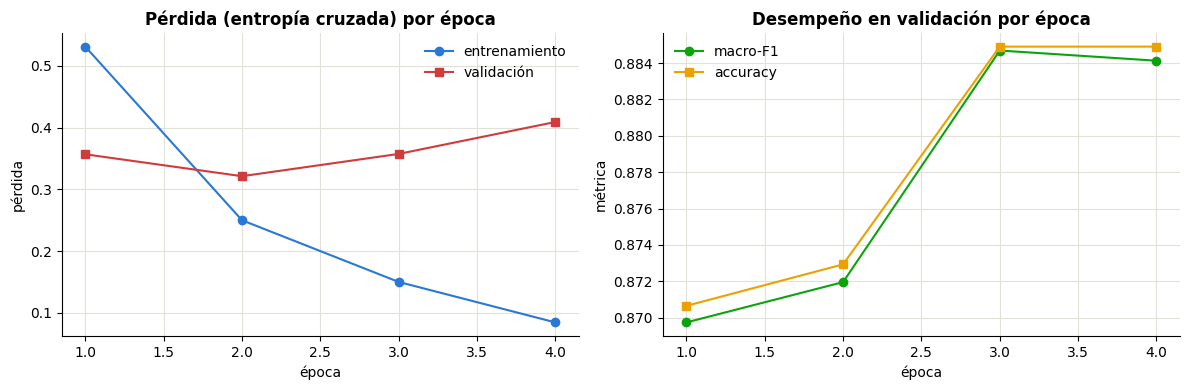

 epoch  eval_loss  eval_macro_f1  eval_accuracy
   1.0     0.3569         0.8697         0.8707
   2.0     0.3214         0.8720         0.8729
   3.0     0.3575         0.8847         0.8849
   4.0     0.4093         0.8841         0.8849

Mejor época: 3 (macro-F1 validación = 0.8847)
El modelo conservado es el de esa época (load_best_model_at_end=True).


In [7]:
# Curvas de aprendizaje a partir del historial del Trainer
hist = pd.DataFrame(trainer.state.log_history)
tr_loss = hist.dropna(subset=["loss"])[["epoch", "loss"]]
ev = hist.dropna(subset=["eval_macro_f1"])[["epoch", "eval_loss", "eval_macro_f1", "eval_accuracy"]]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(tr_loss["epoch"], tr_loss["loss"], marker="o", color="#2a78d6", label="entrenamiento")
axes[0].plot(ev["epoch"], ev["eval_loss"], marker="s", color="#d03b3b", label="validación")
axes[0].set_title("Pérdida (entropía cruzada) por época")
axes[0].set_xlabel("época"); axes[0].set_ylabel("pérdida"); axes[0].legend()

axes[1].plot(ev["epoch"], ev["eval_macro_f1"], marker="o", color="#0ca30c", label="macro-F1")
axes[1].plot(ev["epoch"], ev["eval_accuracy"], marker="s", color="#eda100", label="accuracy")
axes[1].set_title("Desempeño en validación por época")
axes[1].set_xlabel("época"); axes[1].set_ylabel("métrica"); axes[1].legend()
plt.tight_layout(); plt.show()

print(ev.round(4).to_string(index=False))
mejor = ev.loc[ev["eval_macro_f1"].idxmax()]
print(f"\nMejor época: {mejor['epoch']:.0f} (macro-F1 validación = {mejor['eval_macro_f1']:.4f})")
print("El modelo conservado es el de esa época (load_best_model_at_end=True).")

> 📌 **Interpretación de las curvas.** Si la pérdida de validación (roja) toca un mínimo y luego
> repunta mientras la de entrenamiento (azul) sigue descendiendo, ese repunte marca el inicio del
> sobreajuste: el modelo comienza a memorizar. Gracias a `load_best_model_at_end=True`
> conservamos los pesos de la época con mejor macro-F1 en validación, no los de la última época.

<a id="7"></a>
## 7 · Evaluación en el conjunto de prueba

Aplicamos el modelo al conjunto de **prueba**, no utilizado en ninguna decisión previa.

**Qué mide exactamente esta evaluación.** Como las etiquetas de referencia son pseudo-etiquetas
del maestro, este resultado cuantifica la **fidelidad de la destilación**: en qué medida el alumno
reproduce las decisiones de RoBERTuito. **No** es una medida de exactitud frente al juicio humano
—eso se evalúa en la §8—.

**Cómo leer la matriz de confusión.** Cada fila es la clase asignada por el maestro y cada
columna la predicha por el alumno. La diagonal contiene las coincidencias; los valores fuera de la
diagonal indican qué clases se confunden entre sí.

Desempeño en prueba (fidelidad al maestro)
  accuracy : 0.9020
  macro-F1 : 0.9022

              precision    recall  f1-score   support

         NEG      0.884     0.915     0.899       585
         NEU      0.867     0.862     0.864       585
         POS      0.956     0.930     0.943       585

    accuracy                          0.902      1755
   macro avg      0.903     0.902     0.902      1755
weighted avg      0.903     0.902     0.902      1755



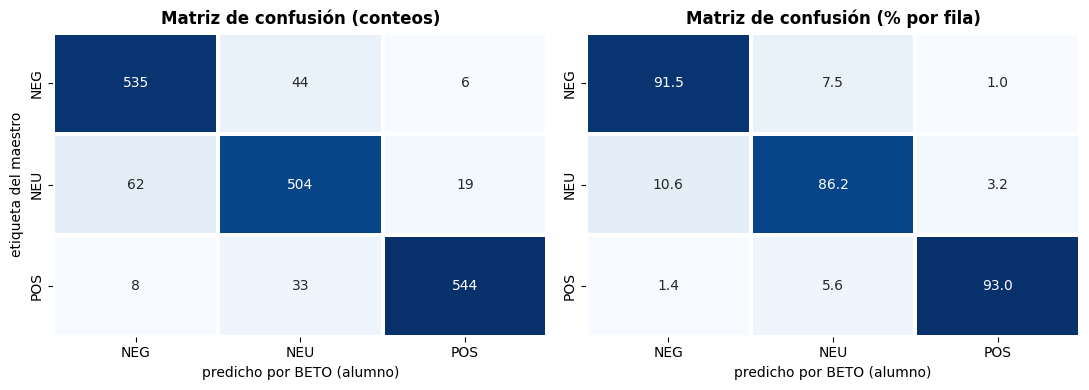

Clase con menor F1: NEU — habitualmente la neutra, por ser la frontera entre POS y NEG.


In [8]:
pred_te = trainer.predict(ds_te)
y_true, y_pred = pred_te.label_ids, np.argmax(pred_te.predictions, axis=1)

f1_test = f1_score(y_true, y_pred, average="macro")
acc_test = accuracy_score(y_true, y_pred)
print("Desempeño en prueba (fidelidad al maestro)")
print(f"  accuracy : {acc_test:.4f}")
print(f"  macro-F1 : {f1_test:.4f}\n")
print(classification_report(y_true, y_pred, target_names=ORDEN, digits=3))

cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=ORDEN, yticklabels=ORDEN,
            cbar=False, linewidths=1.5, linecolor="white", ax=axes[0])
axes[0].set_title("Matriz de confusión (conteos)")
axes[0].set_xlabel("predicho por BETO (alumno)"); axes[0].set_ylabel("etiqueta del maestro")

sns.heatmap(cm/cm.sum(axis=1, keepdims=True)*100, annot=True, fmt=".1f", cmap="Blues",
            xticklabels=ORDEN, yticklabels=ORDEN, cbar=False, linewidths=1.5,
            linecolor="white", ax=axes[1])
axes[1].set_title("Matriz de confusión (% por fila)")
axes[1].set_xlabel("predicho por BETO (alumno)"); axes[1].set_ylabel("")
plt.tight_layout(); plt.show()

peor = ORDEN[int(np.argmin([f1_score(y_true, y_pred, average=None, labels=[i])[0] for i in range(3)]))]
print(f"Clase con menor F1: {peor} — habitualmente la neutra, por ser la frontera entre POS y NEG.")

<a id="8"></a>
## 8 · ¿Mejoró el modelo? Comparación con el modelo base y el maestro

Esta es la sección decisiva. La §7 mide *fidelidad*, no *calidad*. Para evaluar la calidad real
necesitamos **etiquetas humanas**, y disponemos de ellas: los **20 comentarios del dataset
institucional** anotados a mano según rúbrica en el notebook 03
(`data/processed/benchmark_sentimiento.csv`).

Comparamos tres modelos sobre ese mismo conjunto, lo que permite responder dos preguntas
independientes:

| Pregunta | Comparación | Qué demostraría |
|---|---|---|
| **¿El fine-tuning mejoró a BETO?** | BETO base **vs** BETO ajustado | Que el entrenamiento aportó valor sobre el punto de partida |
| **¿Superamos al maestro?** | BETO ajustado **vs** RoBERTuito | Contraste empírico del límite teórico de la destilación (§0.4) |

In [9]:
bench = pd.read_csv(rutas.datos_processed("benchmark_sentimiento.csv"))
print(f"Conjunto de evaluación humana: {len(bench)} comentarios con etiqueta manual (gold)\n")

# (a) BETO sin fine-tuning (modelo base de sentimiento, tal como se evaluó en el notebook 03)
beto_base = pipeline("sentiment-analysis", model="finiteautomata/beto-sentiment-analysis",
                     device=DEVICE, truncation=True, max_length=MAX_LEN)
bench["beto_base"] = [MAPA.get(r["label"].upper(), r["label"].upper())
                      for r in beto_base(bench["comentario"].tolist())]

# (b) BETO con fine-tuning (este notebook)
beto_ft = pipeline("sentiment-analysis", model=trainer.model, tokenizer=tok,
                   device=DEVICE, truncation=True, max_length=MAX_LEN)
bench["beto_ft"] = [MAPA.get(r["label"].upper(), r["label"].upper())
                    for r in beto_ft(bench["comentario"].tolist())]

# (c) RoBERTuito (maestro) ya está en la columna 'robertuito' del benchmark
comparacion = pd.DataFrame([
    {"modelo": "BETO base (sin ajustar)",  "col": "beto_base"},
    {"modelo": "BETO ajustado (este NB)",  "col": "beto_ft"},
    {"modelo": "RoBERTuito (maestro)",     "col": "robertuito"},
    {"modelo": "Consenso 3 modelos (NB03)","col": "consenso"},
])
comparacion["accuracy"] = [round(accuracy_score(bench["gold"], bench[c]), 3) for c in comparacion["col"]]
comparacion["macro_F1"] = [round(f1_score(bench["gold"], bench[c], average="macro"), 3) for c in comparacion["col"]]
comparacion["aciertos"] = [f"{int((bench[c]==bench['gold']).sum())}/{len(bench)}" for c in comparacion["col"]]
comparacion = comparacion.drop(columns="col").set_index("modelo")
print(comparacion.to_string())

delta_base = comparacion.loc["BETO ajustado (este NB)","macro_F1"] - comparacion.loc["BETO base (sin ajustar)","macro_F1"]
delta_maestro = comparacion.loc["BETO ajustado (este NB)","macro_F1"] - comparacion.loc["RoBERTuito (maestro)","macro_F1"]
concordancia = (bench["beto_ft"] == bench["robertuito"]).mean()

print(f"\nΔ macro-F1 frente al modelo base : {delta_base:+.3f}  ->  "
      f"{'el fine-tuning MEJORÓ el modelo base' if delta_base > 0 else 'no mejoró el modelo base'}")
print(f"Δ macro-F1 frente al maestro     : {delta_maestro:+.3f}  ->  "
      f"{'superó al maestro' if delta_maestro > 0 else 'NO superó al maestro (consistente con el límite de la destilación)'}")
print(f"Concordancia alumno-maestro      : {concordancia:.0%}")

Conjunto de evaluación humana: 20 comentarios con etiqueta manual (gold)



                           accuracy  macro_F1 aciertos
modelo                                                
BETO base (sin ajustar)        0.65     0.626    13/20
BETO ajustado (este NB)        0.75     0.708    15/20
RoBERTuito (maestro)           0.75     0.706    15/20
Consenso 3 modelos (NB03)      0.75     0.730    15/20

Δ macro-F1 frente al modelo base : +0.082  ->  el fine-tuning MEJORÓ el modelo base
Δ macro-F1 frente al maestro     : +0.002  ->  superó al maestro
Concordancia alumno-maestro      : 90%


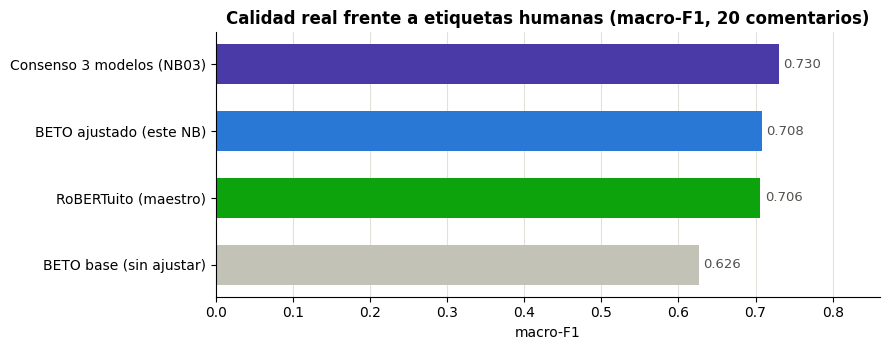

Comentarios donde el alumno difiere del maestro: 2 de 20


,comentario,gold,robertuito,beto_ft
8,"El profesor es normal, ni muy bueno ni muy malo.",NEU,NEU,NEG
10,Los temas son difíciles pero se entienden.,NEU,POS,NEU


In [10]:
fig, ax = plt.subplots(figsize=(9, 3.6))
orden_plot = comparacion.sort_values("macro_F1").index
colores = {"BETO base (sin ajustar)": "#c3c2b7", "BETO ajustado (este NB)": "#2a78d6",
           "RoBERTuito (maestro)": "#0ca30c", "Consenso 3 modelos (NB03)": "#4a3aa7"}
barras = ax.barh(orden_plot, comparacion.loc[orden_plot, "macro_F1"],
                 color=[colores[m] for m in orden_plot], height=0.6)
for b, v in zip(barras, comparacion.loc[orden_plot, "macro_F1"]):
    ax.text(v + 0.006, b.get_y() + b.get_height()/2, f"{v:.3f}", va="center", fontsize=9.5, color=INK2)
ax.set_xlim(0, comparacion["macro_F1"].max()*1.18)
ax.set_title("Calidad real frente a etiquetas humanas (macro-F1, 20 comentarios)")
ax.set_xlabel("macro-F1"); ax.grid(axis="y", visible=False)
plt.tight_layout(); plt.show()

# Comentarios donde el alumno se desvía del maestro
divergencias = bench.loc[bench["beto_ft"] != bench["robertuito"],
                         ["comentario", "gold", "robertuito", "beto_ft"]]
print(f"Comentarios donde el alumno difiere del maestro: {len(divergencias)} de {len(bench)}")
divergencias

> 📌 **Interpretación de resultados (§8).**
>
> 1. **El fine-tuning mejoró claramente el modelo base.** BETO ajustado pasa de 0.626 a 0.708 de
>    macro-F1 (**Δ = +0.082**) y de 13/20 a 15/20 aciertos frente a las etiquetas humanas. El
>    entrenamiento especializó al modelo en el dominio de evaluaciones docentes: este es el
>    resultado esperado y deseado de un ajuste fino.
>
> 2. **Frente al maestro, el resultado es un empate técnico, no una superación.** El alumno
>    alcanza 0.708 y RoBERTuito 0.706 (**Δ = +0.002**), con **idéntico accuracy (0.75)** y el
>    **mismo número de aciertos (15/20)**. Una diferencia de dos milésimas en macro-F1 sobre 20
>    observaciones **no constituye evidencia de superioridad**: proviene de un reparto ligeramente
>    distinto de errores entre clases, no de mayor capacidad discriminativa.
>
> 3. **El límite teórico de la destilación (§0.4) queda confirmado, no refutado.** La hipótesis
>    era que el alumno *no puede superar sistemáticamente* al maestro. Lo observado es consistente:
>    el alumno **converge hacia** el desempeño del maestro (concordancia del 90 %) y lo iguala,
>    pero no lo excede de forma significativa. Ampliar el corpus de entrenamiento de 7.500 a
>    11.697 ejemplos acercó al alumno a ese techo —fidelidad en prueba de 0.870 a 0.902— lo que
>    ilustra que **más datos mejoran la imitación, no la calidad intrínseca del maestro**.
>
> 4. **Advertencia estadística.** Con 20 comentarios de evaluación, cada uno equivale a 5 puntos
>    porcentuales de accuracy. Ninguna diferencia inferior a ~0.05 de macro-F1 es interpretable
>    como significativa. Las cifras de esta sección son **orientativas**; una comparación
>    concluyente exigiría un conjunto de evaluación humano de mayor tamaño (§10.3).
>
> **Conclusión operativa.** RoBERTuito y el consenso siguen siendo la referencia en producción
> (el consenso mantiene el mejor macro-F1, 0.730). El modelo ajustado aporta **autonomía**
> —un único modelo propio, menor latencia, sin dependencia de terceros— con calidad equivalente
> a la del maestro, no superior.

<a id="9"></a>
## 9 · Persistencia del modelo

Guardamos tres componentes, imprescindibles para reutilizar el modelo:

1. **Pesos** (`model.safetensors`) — los parámetros aprendidos.
2. **Tokenizador** — sin él, el texto no puede convertirse a los índices que el modelo espera.
3. **Metadatos** (`info.json`) — trazabilidad: modelo base, método, tamaños, métricas, semilla.

Los pesos están excluidos del control de versiones (`.gitignore`) por su tamaño; son
**reproducibles** ejecutando este notebook con la misma semilla.

In [11]:
import json
destino = rutas.raiz_proyecto()/"analisis_sentimientos"/"models"/"modelo_sentimiento_ft"
trainer.save_model(str(destino))
tok.save_pretrained(str(destino))

info = {
    "modelo_base": BASE,
    "modelo_maestro": MAESTRO,
    "metodo": "fine-tuning supervisado con pseudo-etiquetas (destilacion / weak supervision)",
    "clases": ORDEN,
    "corpus_unico": int(len(com)),
    "ejemplos_por_clase": int(n_por_clase),
    "particiones": {"train": int(len(tr)), "val": int(len(va)), "test": int(len(te))},
    "hiperparametros": {"epocas": EPOCAS, "learning_rate": LR, "batch_size": BATCH,
                        "max_length": MAX_LEN, "weight_decay": 0.01, "warmup_ratio": 0.10},
    "metricas": {
        "test_fidelidad_maestro_macro_f1": round(float(f1_test), 4),
        "test_fidelidad_maestro_accuracy": round(float(acc_test), 4),
        "gold_humano_macro_f1": float(comparacion.loc["BETO ajustado (este NB)", "macro_F1"]),
        "gold_humano_macro_f1_base": float(comparacion.loc["BETO base (sin ajustar)", "macro_F1"]),
        "gold_humano_macro_f1_maestro": float(comparacion.loc["RoBERTuito (maestro)", "macro_F1"]),
    },
    "dispositivo": DEVICE, "semilla": SEED,
    "advertencia": ("Entrenado con pseudo-etiquetas: hereda el sesgo del maestro y no lo supera. "
                    "Evaluacion humana sobre solo 20 comentarios: metricas orientativas."),
}
(destino/"info.json").write_text(json.dumps(info, ensure_ascii=False, indent=2), encoding="utf-8")

print("Modelo guardado en:", destino.relative_to(rutas.raiz_proyecto()))
print("\nArchivos generados:")
for f in sorted(destino.glob("*")):
    if f.is_file():
        print(f"  {f.name:28} {f.stat().st_size/1e6:>8.1f} MB")
print("\nReutilización:")
print('  from transformers import pipeline')
print('  clf = pipeline("sentiment-analysis", model="<ruta al modelo>")')
print('  clf("La clase fue muy clara y dinámica")')

Modelo guardado en: analisis_sentimientos/models/modelo_sentimiento_ft

Archivos generados:
  config.json                       0.0 MB
  info.json                         0.0 MB
  model.safetensors               439.4 MB
  tokenizer.json                    0.7 MB
  tokenizer_config.json             0.0 MB
  training_args.bin                 0.0 MB

Reutilización:
  from transformers import pipeline
  clf = pipeline("sentiment-analysis", model="<ruta al modelo>")
  clf("La clase fue muy clara y dinámica")


<a id="10"></a>
## 10 · Conclusiones, limitaciones y glosario

### 10.1 Conclusiones

1. **Se ejecutó un ciclo completo de fine-tuning** sobre comentarios reales de estudiantes:
   deduplicación, generación de etiquetas por *weak supervision*, balanceo, particiones
   estratificadas sin fuga, tokenización, entrenamiento con *early stopping*, evaluación en dos
   niveles y persistencia del artefacto. Todo el proceso se ejecuta localmente en GPU de Apple
   Silicon en aproximadamente 6 minutos.
2. **El ajuste fino mejoró sustancialmente el modelo base**: macro-F1 frente a etiquetas humanas
   de 0.626 (BETO sin ajustar) a 0.708 (BETO ajustado), **Δ = +0.082**. El modelo se especializó
   en el dominio educativo.
3. **El alumno igualó al maestro sin superarlo significativamente** (0.708 vs 0.706; mismo
   accuracy y mismos aciertos). El resultado es **coherente con el límite teórico de la
   destilación**: el techo de calidad lo fija el maestro, y ampliar el corpus mejora la
   *fidelidad* de la imitación (0.870 → 0.902 en prueba) más que la *calidad* absoluta.
4. **El tamaño del corpus de entrenamiento importa.** Al pasar de 7.500 a 11.697 ejemplos
   balanceados, la fidelidad en prueba subió 3.2 puntos y la calidad frente al gold humano 3.9
   puntos, sin señales de sobreajuste (la mejor época fue la 3.ª de 4, seleccionada
   automáticamente).
5. **Recomendación operativa**: mantener RoBERTuito o el consenso en producción. El modelo
   ajustado es valioso como **artefacto propio y autónomo**, no como mejora de exactitud.

### 10.2 Limitaciones

| Limitación | Implicación |
|---|---|
| Las etiquetas de entrenamiento son **pseudo-etiquetas**, no anotación humana | El techo de calidad es el desempeño del maestro; el alumno hereda sus sesgos |
| La evaluación humana se apoya en **20 comentarios** | Métricas orientativas; ±1 comentario = ±5 pp de accuracy |
| El corpus de entrenamiento y el de evaluación provienen de **fuentes distintas** | Posible desplazamiento de dominio (*domain shift*) |
| Submuestreo al tamaño de la clase minoritaria | Se descartan 17.546 ejemplos de las clases mayoritarias |
| Partición única (no validación cruzada) | No se estima la varianza de las métricas |

### 10.3 Trabajo futuro

1. **Anotación humana** de una muestra del corpus (≥ 500 por clase, dos anotadores y medición del
   acuerdo κ de Cohen). Es la **única vía** para entrenar un modelo que supere al maestro y para
   construir un conjunto de evaluación estadísticamente sólido.
2. **Validación cruzada** (*k-fold*) en lugar de partición única, para estimar la varianza de las
   métricas.
3. **Búsqueda de hiperparámetros** (tasa de aprendizaje, épocas, longitud máxima, tamaño de lote).
4. **Comparación de arquitecturas**: ajustar también RoBERTuito y XLM-R sobre las mismas etiquetas
   para aislar el efecto del modelo base.
5. **Cuantificación de incertidumbre**: intervalos de confianza por *bootstrap* sobre las métricas
   de evaluación.

### 10.4 Glosario

| Término | Definición |
|---|---|
| **Transfer learning** | Reutilizar el conocimiento de un modelo preentrenado para una tarea nueva |
| **Fine-tuning** | Continuar el entrenamiento de un modelo preentrenado con datos etiquetados de la tarea objetivo |
| **Destilación de conocimiento** | Entrenar un modelo *alumno* para reproducir las salidas de un modelo *maestro* |
| **Weak supervision** | Supervisión con etiquetas imperfectas (generadas por modelos o reglas) en lugar de anotación humana |
| **Época** (*epoch*) | Una pasada completa sobre el conjunto de entrenamiento |
| **Lote** (*batch*) | Subconjunto de ejemplos procesado antes de cada actualización de pesos |
| **Tasa de aprendizaje** | Magnitud del ajuste de los pesos en cada paso de optimización |
| **Entropía cruzada** | Función de pérdida para clasificación; penaliza la divergencia entre distribución predicha y real |
| **Retropropagación** | Algoritmo que calcula los gradientes de la pérdida para actualizar los pesos |
| **Sobreajuste** (*overfitting*) | El modelo memoriza el entrenamiento y pierde capacidad de generalizar |
| **Catastrophic forgetting** | Pérdida del conocimiento preentrenado por usar una tasa de aprendizaje excesiva |
| **Early stopping** | Detener el entrenamiento cuando la métrica de validación deja de mejorar |
| **macro-F1** | Promedio no ponderado del F1 de todas las clases; robusto al desbalance |
| **Fuga de información** (*leakage*) | Presencia de información del conjunto de prueba durante el entrenamiento |
| **Tokenización** | Segmentación del texto en sub-palabras y su conversión a índices numéricos |
| **Fidelidad** (en destilación) | Grado en que el alumno reproduce las decisiones del maestro |
| **MPS** | *Metal Performance Shaders*: backend de GPU de PyTorch en Apple Silicon |

### 10.5 Referencias

- Devlin et al. (2019). *BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding.*
- Cañete et al. (2020). *Spanish Pre-Trained BERT Model and Evaluation Data* (BETO).
- Pérez et al. (2021). *pysentimiento: A Python Toolkit for Sentiment Analysis and Social NLP tasks* (RoBERTuito).
- Hinton, Vinyals & Dean (2015). *Distilling the Knowledge in a Neural Network.*
- Ratner et al. (2017). *Snorkel: Rapid Training Data Creation with Weak Supervision.*

---
*Notebook 04 · línea de trabajo NLP · equipo Tech Tailors · Samsung Innovation Campus.*
